In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:\work\Internship\Task 3\Titanic_train.csv")

In [3]:
df.head(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S


In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
#Total passengers count karo
df['PassengerId'].count()

np.int64(891)

In [7]:
#average age find kro
df['Age'].mean()

np.float64(29.69911764705882)

In [8]:
# max or min fare(kiraya) find kro 
max = df['Fare'].max()
min = df['Fare'].min()
print(f" max fare is: {max}")
print(f" min fare is: {min}")
max = df

 max fare is: 512.3292
 min fare is: 0.0


In [9]:
#Kitne passengers survive hue aur kitne nahi
survived = df['Survived'].sum()
not_survived = len(df) - survived
print(f"Survived: {survived}")
print(f"not Survived: {not_survived}")

Survived: 342
not Survived: 549


In [10]:
# Male aur Female passengers kitne hain
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [11]:
# Passengers kis port se embark hue (Embarked column)
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: xlabel='Sex', ylabel='count'>

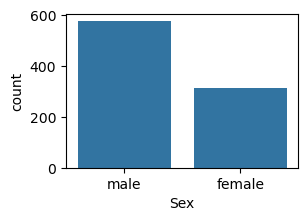

In [13]:
# TOTAL male and femles
plt.figure(figsize=(3,2))
sns.countplot(x = 'Sex', data = df)

#### -> Male me kitne survive hue or Female me kitne survive hue

In [14]:
# ROUGH method
df[['Survived','Sex']].value_counts() 

Survived  Sex   
0         male      468
1         female    233
          male      109
0         female     81
Name: count, dtype: int64

In [15]:
df.groupby('Sex')['Survived'].sum()

Sex
female    233
male      109
Name: Survived, dtype: int64

<Axes: xlabel='Sex', ylabel='count'>

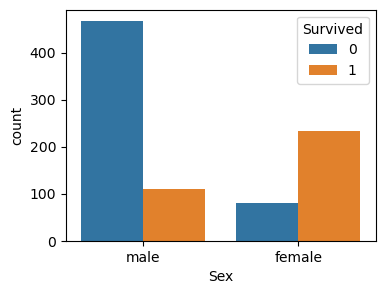

In [16]:
plt.figure(figsize=(4,3))
sns.countplot(x='Sex', hue = 'Survived', data=df)

### -> Male or female kitny survive nahi kr paye 

In [17]:
m_ns = df[(df['Sex'] == 'male') & (df['Survived'] == 0)].shape[0]
f_ns = df[(df['Sex']== 'female') & (df['Survived'] == 0)].shape[0]
print(f"{m_ns} male not Survived")
print(f"{f_ns} female not Survived")

468 male not Survived
81 female not Survived


### -> Which passenger class had the highest survival rate?

In [18]:
survive = df.groupby('Pclass')['Survived'].sum()
print(survive)

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64


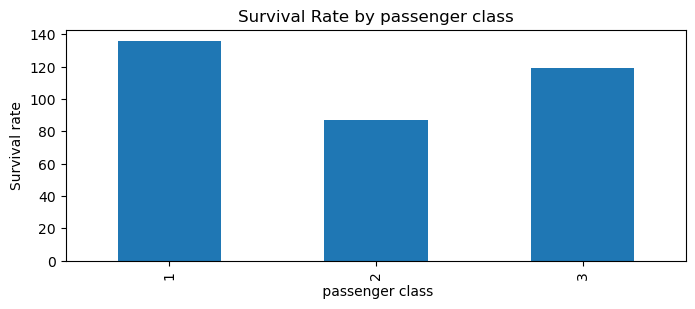

In [19]:
plt.figure(figsize=(8,3))
survive.plot(kind = "bar")
plt.title("Survival Rate by passenger class")
plt.xlabel(" passenger class")
plt.ylabel("Survival rate")
plt.show()

### -> Which class paid the highest fare?


In [20]:
df.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

- Graph representation which class paid highest fare

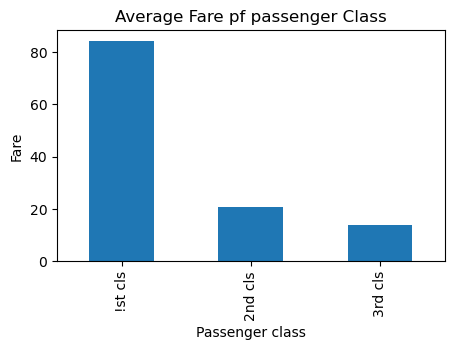

In [21]:
plt.figure(figsize=(5,3))
fare = df.groupby('Pclass')['Fare'].mean()
fare.index = ['!st cls','2nd cls','3rd cls']
fare.plot(kind = 'bar')
plt.title('Average Fare pf passenger Class')
plt.xlabel('Passenger class')
plt.ylabel('Fare')
plt.show()

In [22]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [23]:
df['Family_size'] = df['SibSp'] + df['Parch']+1

In [24]:
df[['Name','SibSp','Parch', 'Family_size']].head()

,Name,SibSp,Parch,Family_size
0,"Braund, Mr. Owen Harris",1,0,2
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0,2
2,"Heikkinen, Miss. Laina",0,0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0,2
4,"Allen, Mr. William Henry",0,0,1
